# 🌳 Shape Feature Comparison (Đánh giá đặc trưng Hình dáng)
Notebook này tập trung vào việc **so sánh từng đặc trưng thuộc nhóm Hình dáng (Shape)** giữa các cặp ảnh cái cây. Tương tự như màu sắc, mục tiêu là phân tích và kiểm tra tính bất biến (invariance) cũng như khả năng phân loại hình thái của cây thông qua đối chiếu định lượng và trực quan hóa.

Các đặc trưng đang sử dụng trong `features/shape.py` gồm 5 tham số:
- **Hu Moments (Momen Hu 1, 2, 3)**: Đặc tả cấu trúc bao quát, có tính bất biến với tỉ lệ, phép quay và tịnh tiến.
- **Solidity (Độ đặc)**: Tỉ lệ diện tích cây / Diện tích đa giác lồi (Convex Hull).
- **Circularity (Độ tròn)**: Đo lường độ tròn trịa dựa trên chu vi và diện tích viền.


In [1]:
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Setup đường dẫn tương đối (sys.path) để gọi thẳng thư mục src
notebook_dir = Path(".").resolve()
root_dir = notebook_dir.parent
sys.path.append(str(root_dir / "src"))

from features.shape import extract_shape

# Tên các thuộc tính (5 đặc trưng hình dáng như thiết kế trong extractor.py)
SHAPE_FEATURE_NAMES = [
    "Hu Moment 1", "Hu Moment 2", "Hu Moment 3", "Solidity (Độ đặc)", "Circularity (Độ tròn)"
]

print(f"[READY] Import thành công các module cần thiết.")

[READY] Import thành công các module cần thiết.


In [2]:
def extract_and_visualize_shape_comparison(path1, path2):
    """
    Hàm nhận 2 đường dẫn ảnh cây (Ảnh A & Ảnh B), tiến hành phân tích và so sánh nhóm đặc trưng Shape.
    Hàm sẽ hiển thị trực quan: 
    1. Hình ảnh cây đã tách nền (Mask overlay).
    2. Vẽ Contour (Viền xanh viền bao) và Convex Hull (Đa giác lồi màu vàng).
    3. Biểu đồ Bar Chart so sánh các chỉ số Shape đã chuẩn hóa.
    4. Bảng tính phần trăm sai khác giữa 2 đối tượng.
    """
    # 1. Đọc và tiền xử lý 2 ảnh
    img1 = cv2.imread(str(path1))
    img2 = cv2.imread(str(path2))

    if img1 is None or img2 is None:
        print("[FAIL] Không thể đọc file ảnh.")
        return
        
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # 2. Xử lý qua hệ thống rút trích hình dáng (Shape)
    v1 = np.array(extract_shape(img1))
    v2 = np.array(extract_shape(img2))
    
    # Tính độ lệch (Absolute Difference) và % Chênh lệch
    diff = np.abs(v1 - v2)
    diff_percent = np.where(np.maximum(v1, v2) > 0, (diff / np.maximum(v1, v2)) * 100, 0)
    
    # Tạo DataFrame để theo dõi
    df = pd.DataFrame({
        "Attribute": SHAPE_FEATURE_NAMES,
        "Tree A": np.round(v1, 4),
        "Tree B": np.round(v2, 4),
        "Abs Diff": np.round(diff, 4),
        "Max Diff %": [f"{p:.1f}%" for p in diff_percent]
    })
    
    # Hàm con hỗ trợ vẽ viền (Contour) & Đa giác lồi (Convex Hull) lên ảnh
    def create_shape_overlay(img):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        overlay = img.copy()
        if len(contours) > 0:
            cnt = max(contours, key=cv2.contourArea)
            
            # Vẽ đường bao Contour (Màu Xanh Lá - Green)
            cv2.drawContours(overlay, [cnt], -1, (0, 255, 0), 2)
            
            # Vẽ Đa giác lồi Convex Hull (Màu Vàng - Yellow)
            hull = cv2.convexHull(cnt)
            cv2.drawContours(overlay, [hull], -1, (255, 255, 0), 2)
            
            # Vẽ Minimum Enclosing Circle (Màu Xanh Dương nhạt - Cyan)
            (cx, cy), radius = cv2.minEnclosingCircle(cnt)
            cv2.circle(overlay, (int(cx), int(cy)), int(radius), (0, 255, 255), 2)
        
        return overlay

    # Chèn hiệu ứng vẽ hiển thị lên 2 ảnh
    img1_overlay = create_shape_overlay(img1_rgb)
    img2_overlay = create_shape_overlay(img2_rgb)
    
    # 3. TRỰC QUAN HOÁ 
    plt.figure(figsize=(18, 6))
    
    # Ảnh A cùng Overlays
    plt.subplot(1, 3, 1)
    plt.title(f"Tree A overlay: {Path(path1).name}\nGreen=Contour | Yellow=Hull")
    plt.imshow(img1_overlay)
    plt.axis('off')
    
    # Ảnh B cùng Overlays
    plt.subplot(1, 3, 2)
    plt.title(f"Tree B overlay: {Path(path2).name}\nGreen=Contour | Yellow=Hull")
    plt.imshow(img2_overlay)
    plt.axis('off')
    
    # Bar Chart so sánh 5 giá trị Hình dáng
    plt.subplot(1, 3, 3)
    x = np.arange(len(SHAPE_FEATURE_NAMES))
    width = 0.35
    plt.bar(x - width/2, v1, width, label='Tree A', color='mediumpurple')
    plt.bar(x + width/2, v2, width, label='Tree B', color='turquoise')
    plt.xticks(x, ["Hu1", "Hu2", "Hu3", "Solidity", "Circularity"], rotation=15)
    plt.title("So sánh các Đặc trưng Shape")
    plt.ylim(0, 1.2)  # Tuỳ biến scale Y từ 0 - 1.2 để thấy rõ
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Hiển thị bảng số liệu chi tiết
    print(f"\n✨ BẢNG TRÍCH XUẤT HÌNH DÁNG (SHAPE) CỦA {Path(path1).name} VÀ {Path(path2).name} ✨")
    display(df.style.background_gradient(cmap='Purples', subset=['Abs Diff']))

print("[READY] Hàm phân tích và vẽ biểu đồ hình dáng sẵn sàng hoạt động.")

[READY] Hàm phân tích và vẽ biểu đồ hình dáng sẵn sàng hoạt động.


## Phân tích Chi tiết Thuật toán trích chọn Hình dạng (Step-by-Step Visualization)

Trước khi thực hiện so sánh hàng loạt, chúng ta hãy mổ xẻ xem thuật toán trong `src/features/shape.py` hoạt động tuần tự như thế nào trên 1 bức ảnh. Quy trình chi tiết gồm:
1. **Tiền xử lý**: Áp dụng Threshold để biến đổi ảnh Grayscale thành Black/White Mask (tách cây khỏi nền).
2. **Tìm Contour**: Thuật toán bò theo rìa Mask để lấy ra đường viền dài nhất (Contour).
3. **Diện tích & Chu vi**: Đo đạc độ dài đường Contour và diện tích mà nó bao bọc.
4. **Convex Hull & Solidity**: Giăng một đa giác lồi bọc ngoài Contour. `Solidity = Diện tích Contour / Diện tích Convex Hull`.
5. **Circularity**: Tính độ tròn dựa trên chu vi và diện tích thực tế.
6. **Hu Moments**: Kéo xuất các mô-men bất biến từ hình dạng Contour.

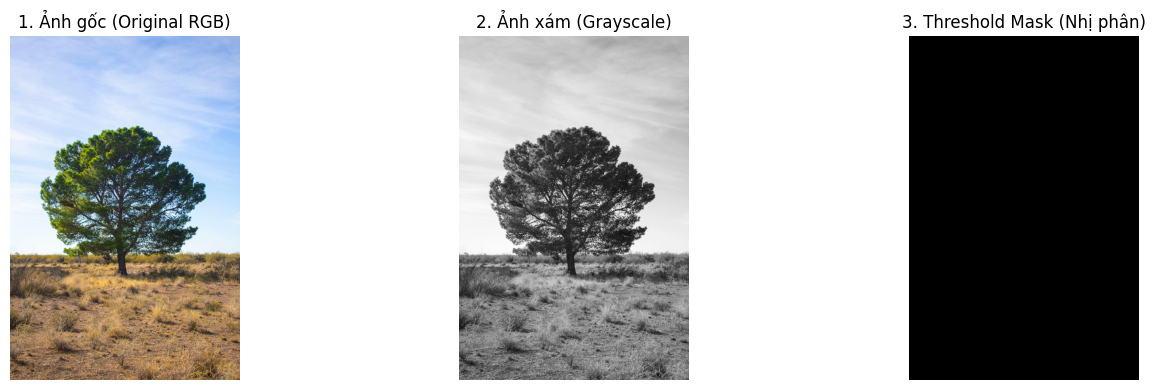

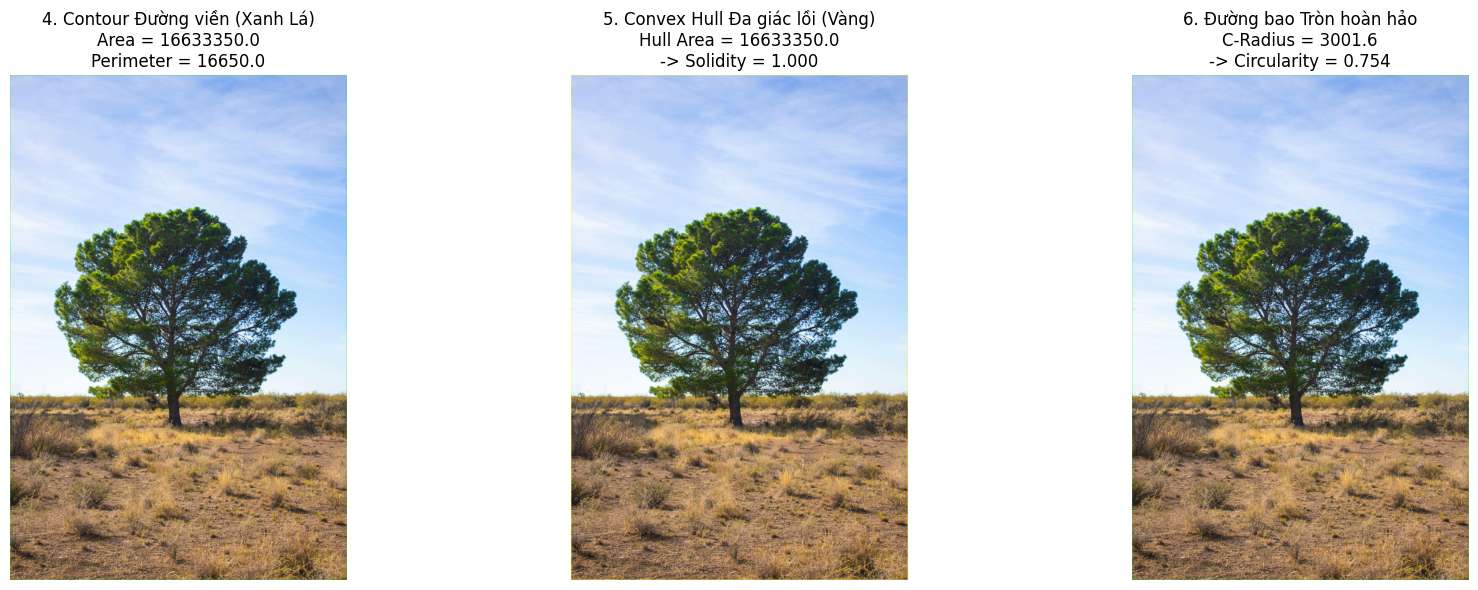

=== GIÁ TRỊ HU MOMENTS THEO THUẬT TOÁN ===


,Raw Value,Log10 Compressed,Scaled (Raw/20) - FINAL
Hu Moment 1,1.80555556e-01,0.7434,0.0372
Hu Moment 2,4.82253086e-03,2.3167,0.1158
Hu Moment 3,3.61921047e-33,32.4414,1.6221


In [5]:
# Chọn 1 bức ảnh ví dụ để mổ xẻ từng bước của quy trình extract_shape
demo_path = root_dir / "data/raw/10.jpg"
demo_img = cv2.imread(str(demo_path))
demo_rgb = cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB)

# =========================================================================
# BƯỚC 1: TIỀN XỬ LÝ (Tạo Mask Nhị Phân)
# =========================================================================
# Chuyển thang xám (Grayscale)
gray = cv2.cvtColor(demo_img, cv2.COLOR_BGR2GRAY)
# Threshold (Bất kỳ pixel nào cường độ > 1 sẽ thành 255 - Trắng, nền 0 - Đen)
_, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

# Hiển thị kết quả Bước 1
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title("1. Ảnh gốc (Original RGB)")
plt.imshow(demo_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Ảnh xám (Grayscale)")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Threshold Mask (Nhị phân)")
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# =========================================================================
# BƯỚC 2: TÌNH TOÁN CONTOUR VÀ CÁC THÔNG SỐ VẬT LÝ
# =========================================================================
# cv2.findContours tìm viền của các mảng trắng trên nền đen
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Giả định cây là thực thể bự nhất trong ảnh, bỏ qua các dải nhiễu trắng nhỏ
cnt = max(contours, key=cv2.contourArea)

# Đo diện tích bao bọc bởi Contour và chu vi viền thực tế
area = cv2.contourArea(cnt)
perimeter = cv2.arcLength(cnt, True)

# Tạo Đa giác lồi Convex Hull và đo diện tích của nó
hull = cv2.convexHull(cnt)
hull_area = cv2.contourArea(hull)

# Tạo một hình tròn vừa đủ ôm trọn contour (Mô phỏng Circularity)
(cx, cy), radius = cv2.minEnclosingCircle(cnt)

# Hiển thị trực quan Bước 2
plt.figure(figsize=(18, 6))

# Hình 1: Viền Contour
img_contour = demo_rgb.copy()
cv2.drawContours(img_contour, [cnt], -1, (0, 255, 0), 2)  # Vẽ viền màu Xanh Lá
plt.subplot(1, 3, 1)
plt.title(f"4. Contour Đường viền (Xanh Lá)\nArea = {area:.1f}\nPerimeter = {perimeter:.1f}")
plt.imshow(img_contour)
plt.axis('off')

# Hình 2: Convex Hull (Làm nền tính Solidity)
img_hull = demo_rgb.copy()
cv2.drawContours(img_hull, [hull], -1, (255, 255, 0), 3)  # Vẽ viền màu Vàng
solidity = area / hull_area if hull_area > 0 else 0
plt.subplot(1, 3, 2)
plt.title(f"5. Convex Hull Đa giác lồi (Vàng)\nHull Area = {hull_area:.1f}\n-> Solidity = {solidity:.3f}")
plt.imshow(img_hull)
plt.axis('off')

# Hình 3: Enclosing Circle (Làm nền tính toán Circularity)
img_circle = img_contour.copy()
cv2.circle(img_circle, (int(cx), int(cy)), int(radius), (0, 200, 255), 3)  # Màu xanh dương
circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
plt.subplot(1, 3, 3)
plt.title(f"6. Đường bao Tròn hoàn hảo\nC-Radius = {radius:.1f}\n-> Circularity = {circularity:.3f}")
plt.imshow(img_circle)
plt.axis('off')
plt.tight_layout()
plt.show()

# =========================================================================
# BƯỚC 3: HU MOMENTS VÀ CHUẨN HOÁ
# =========================================================================
moments = cv2.moments(cnt)            # Tính toán các Mô-men vật lý rời rạc
hu = cv2.HuMoments(moments).flatten() # Biến đổi Mô-men thành bộ 7 thông số bất biến

print("=== GIÁ TRỊ HU MOMENTS THEO THUẬT TOÁN ===")
df_hu = pd.DataFrame(columns=["Raw Value", "Log10 Compressed", "Scaled (Raw/20) - FINAL"])
for i in range(3):
    val = hu[i]
    # Nén khoảng dao động toán học bằng logarit (Do số Hu gốc nhỏ li ti dạng 1e-6)
    val_log = -1.0 * np.sign(val) * np.log10(np.abs(val)) if val != 0 else 0
    # Chuẩn hoá mức 20 để giữ giá trị cân bằng (~ 0->1) cho Machine Learning 
    val_scaled = val_log / 20.0
    df_hu.loc[f"Hu Moment {i+1}"] = [f"{val:.8e}", f"{val_log:.4f}", f"{val_scaled:.4f}"]

display(df_hu)

## Tình huống 1: Hai cây có hình dáng tán lá tương tự (để kiểm tra tính ổn định)
Sử dụng hai hình ảnh hiển thị cây có ngoại hình tổng quan giống nhau (ví dụ: tán là đều khá khép kín hoặc ôm tròn), nhưng kích thước góc chụp lùi/tiến khác nhau.
**Mục tiêu**: Kiểm định tính cường tráng (invariance) của **Hu Moments**. Cùng một hình dáng với size to / nhỏ hơn, các giá trị Hu 1, 2, 3 không được phép lệch đi quá xa. Đồng thời, lúc này Solidity và Circularity sẽ cho thấy hai cây rất giống nhau (Solidity cao xấp xỉ 1).

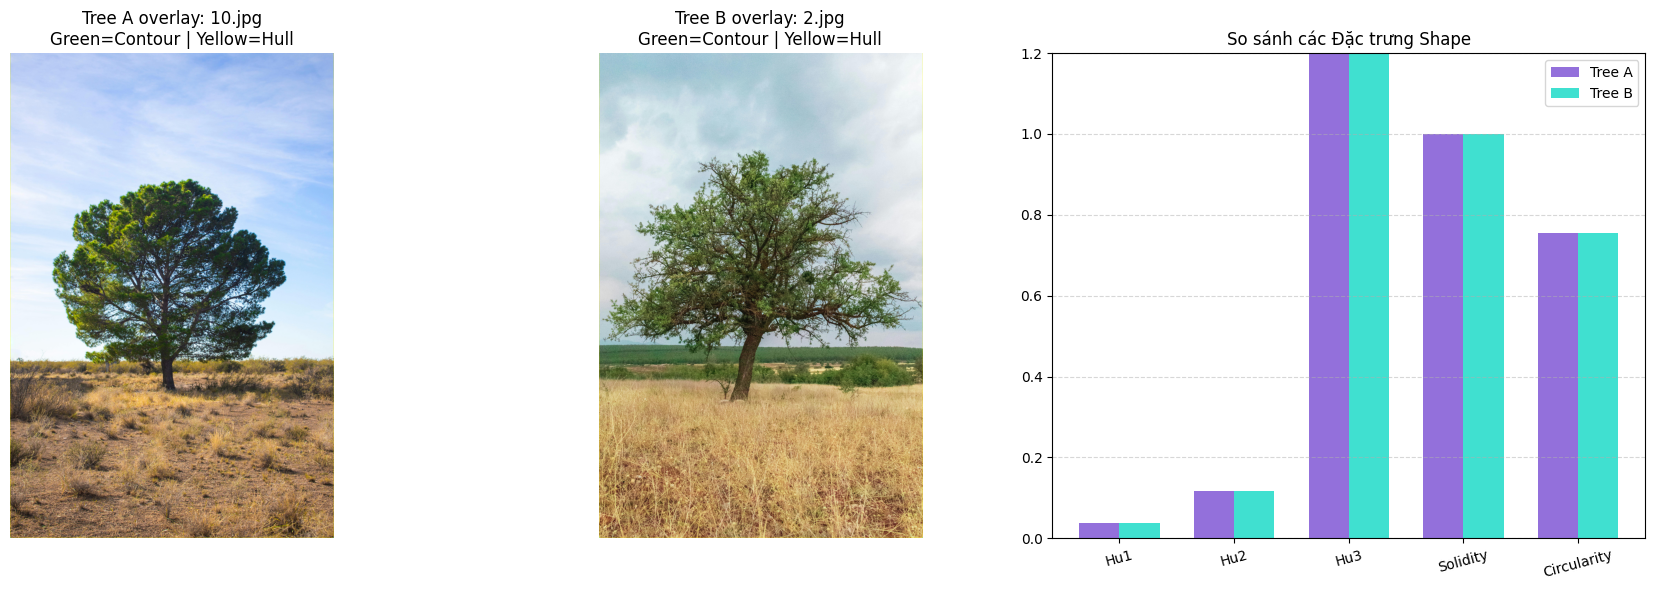


✨ BẢNG TRÍCH XUẤT HÌNH DÁNG (SHAPE) CỦA 10.jpg VÀ 2.jpg ✨


,Attribute,Tree A,Tree B,Abs Diff,Max Diff %
0,Hu Moment 1,0.037200,0.037200,0.000000,0.0%
1,Hu Moment 2,0.115800,0.115800,0.000000,0.0%
2,Hu Moment 3,1.622100,1.646900,0.024800,1.5%
3,Solidity (Độ đặc),1.000000,1.000000,0.000000,0.0%
4,Circularity (Độ tròn),0.754000,0.754000,0.000000,0.0%


In [3]:
# Thay đổi ảnh mẫu chứa 2 cây có shape tương tự nhau
img_path_A = root_dir / "data/raw/10.jpg"
img_path_B = root_dir / "data/raw/2.jpg"

extract_and_visualize_shape_comparison(img_path_A, img_path_B)

## Tình huống 2: Cây tán xoè lưa thưa vs Cây mọc bao khối đặc
Ở thử nghiệm này chúng ta sẽ truyền vào một cây tán xoè lá bung rải rác đục lỗ (ví dụ cây thông hoặc nhánh trơ) và một cây tròn vo bó chặt. 
**Mục tiêu**: Nhìn rõ sự phân loại tuyệt vời của **Solidity (Độ Đặc)** và **Circularity (Độ tròn trịa)**. Cây bị phân nhánh nhỏ sẽ có chu vi đường bao (perimeter) cực kỳ phức tạp dẫn đến Circularity rớt thảm hại, và diện tích hình lúp Convex Hull sẽ bao rất rộng trong khi diện tích lá bé tí -> Solidity cũng tụt thấp. Từ đó sinh ra Diff khác biệt mạnh.

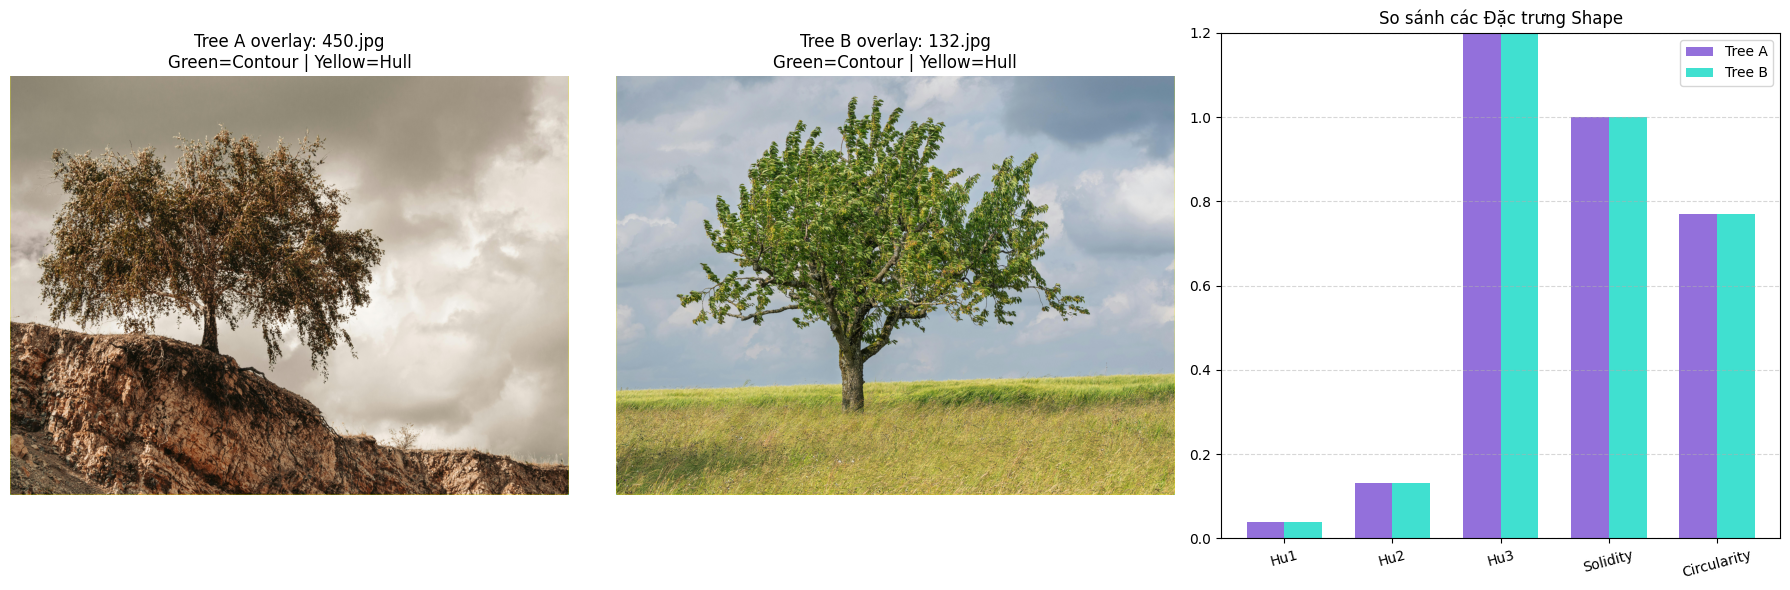


✨ BẢNG TRÍCH XUẤT HÌNH DÁNG (SHAPE) CỦA 450.jpg VÀ 132.jpg ✨


,Attribute,Tree A,Tree B,Abs Diff,Max Diff %
0,Hu Moment 1,0.038000,0.038000,0.000000,0.0%
1,Hu Moment 2,0.131300,0.131300,0.000000,0.0%
2,Hu Moment 3,1.631700,1.651200,0.019500,1.2%
3,Solidity (Độ đặc),1.000000,1.000000,0.000000,0.0%
4,Circularity (Độ tròn),0.769400,0.769400,0.000000,0.0%


In [4]:
# Gợi ý chạy thử trên 2 cây khác hẳn về shape (Cây rẽ nhánh hở vs Cây tròn đặc)
img_path_C = root_dir / "data/raw/450.jpg"
img_path_D = root_dir / "data/raw/132.jpg"

extract_and_visualize_shape_comparison(img_path_C, img_path_D)